# Flocking Dynamics

We display both particle trajectories and per-particle velocity vectors.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

N = 70
X = rng.uniform(-1,1,size=(N,2))
V = rng.normal(scale=0.2,size=(N,2))
dt = 0.04
steps = 140
traj = [X.copy()]
vshow = []
for _ in range(steps):
    d = X[:,None,:]-X[None,:,:]
    dist2 = np.sum(d**2,axis=2) + np.eye(N)
    W = np.exp(-dist2/0.35)
    V = 0.95*V + 0.25*((W @ V)/(W.sum(axis=1,keepdims=True)+1e-12)-V)
    X = X + dt*V
    traj.append(X.copy()); vshow.append(V.copy())
traj = np.array(traj)


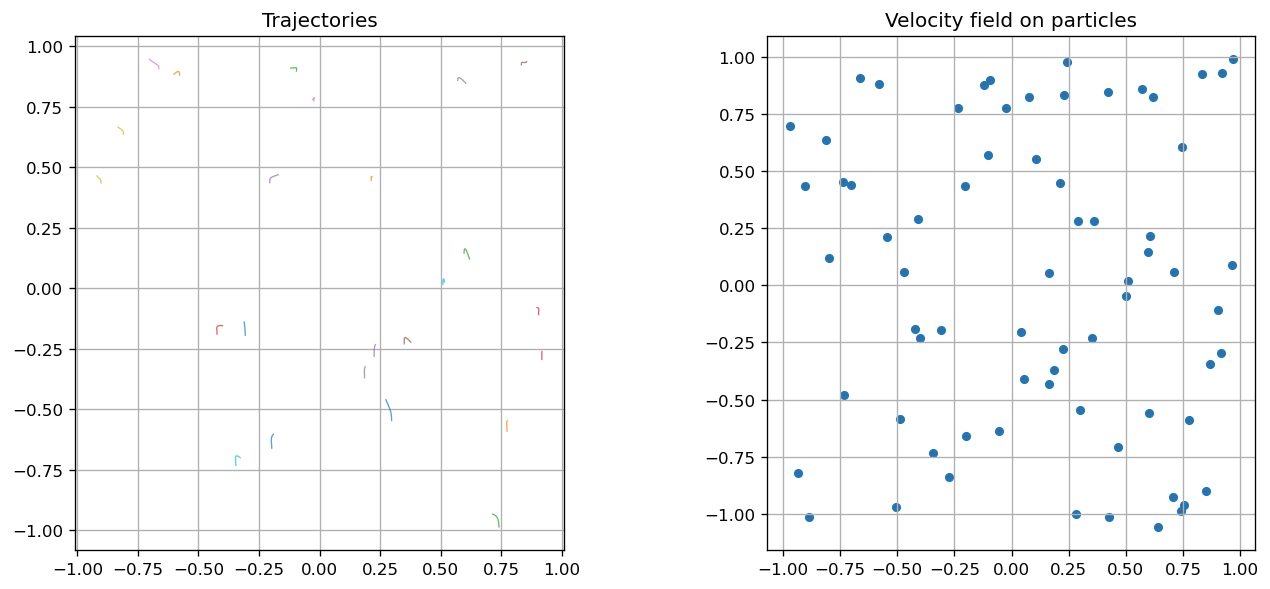

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), constrained_layout=True)
for i in range(0, N, 3):
    axes[0].plot(traj[:,i,0], traj[:,i,1], lw=0.8, alpha=0.7)
axes[0].set_title("Trajectories")
axes[0].set_aspect('equal')

Xf = traj[-1]; Vf = vshow[-1]
axes[1].scatter(Xf[:,0], Xf[:,1], s=20, c='tab:blue')
axes[1].quiver(Xf[:,0], Xf[:,1], Vf[:,0], Vf[:,1], angles='xy', scale_units='xy', scale=1, width=0.004, color='tab:red')
axes[1].set_title("Velocity field on particles")
axes[1].set_aspect('equal')
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()
